In [ ]:
###计算β
import re
def process_data_lammbda_sort(file_path):
    target_groups = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        i = 0
        while i < len(lines):
            metric_line = lines[i].strip()
            metric_dict_line = lines[i + 1].strip()
            param_line = lines[i + 2].strip()
            if "alpha" in param_line :
                # 提取指标字典部分并转换为字典对象
                metric_dict = eval(metric_dict_line)
                # 提取参数部分并分割为单个参数
                params = param_line.split(', ')
                param_dict = {}
                for param in params:
                    key, value = param.split('=')
                    param_dict[key] = float(value) if value.replace('.', '', 1).isdigit() else value
                target_groups.append((param_dict, metric_dict))
            i=i+4

    sorted_groups = sorted(target_groups, key=lambda x: x[0].get('beta'))
    return sorted_groups


file_name_mapping = {
    "scMultiSim1/metrics_scMultiSim1_param.txt":"Simulation4",
    "scMultiSim4/metrics_scMultiSim4_param.txt":"Simulation1",
    "Simulation_triple/metrics_Simulation_triple_param.txt":"Simulation2",
    "scMultiSim5/metrics_scMultiSim5_param.txt":"Simulation6",

}

# 用于存储所有要作为后续输入的打印内容
all_print_content = []

for txt_file_name in file_name_mapping.keys():
    file_path = "/home/lixiangyu/multi-omics/MOMG/input/" + txt_file_name
    sorted_data_lammbda = process_data_lammbda_sort(file_path)

    ami_values = []
    nmi_values = []
    ari_values = []
    homogeneity_values = []
    v_measure_values = []
    mutual_info_values = []
    silhouette_coefficient_values = []
    calinski_Harabasz_index_values = []
    davies_bouldin_index_values = []

    # 循环处理每个group，从group[1]字典中获取对应指标值添加到相应列表
    for group in sorted_data_lammbda:
        metric_dict = group[1]
        ami_values.append(metric_dict.get('AMI'))
        nmi_values.append(metric_dict.get('NMI'))
        ari_values.append(metric_dict.get('ARI'))
        homogeneity_values.append(metric_dict.get('Homogeneity'))
        v_measure_values.append(metric_dict.get('V-measure'))
        mutual_info_values.append(metric_dict.get('Mutual Information'))
        silhouette_coefficient_values.append(metric_dict.get('Silhouette Coefficient'))
        calinski_Harabasz_index_values.append(metric_dict.get('Calinski-Harabasz Index'))
        davies_bouldin_index_values.append(metric_dict.get('Davies-Bouldin Index'))

    # 按照之前的打印格式，将内容添加到all_print_content列表中
    all_print_content.append(f"#{file_name_mapping[txt_file_name]}")
    all_print_content.append("AMI: " + str(ami_values))
    all_print_content.append("NMI: " + str(nmi_values))
    all_print_content.append("ARI: " + str(ari_values))
    all_print_content.append("Homogeneity: " + str(homogeneity_values))
    all_print_content.append("V-measure: " + str(v_measure_values))
    all_print_content.append("Mutual Information: " + str(mutual_info_values))
    # all_print_content.append("Silhouette Coefficient: " + str(silhouette_coefficient_values))
    # all_print_content.append("Calinski-Harabasz Index: " + str(calinski_Harabasz_index_values))
    # all_print_content.append("Davies-Bouldin Index: " + str(davies_bouldin_index_values))
    all_print_content.append("")  # 每个文件结果之间空一行，方便区分，可根据需要调整

# 将收集的所有打印内容转换为字符串，模拟之前的lines格式
lines = "\n".join(all_print_content)

data_β = {}
current_dataset = ""
current_metric = ""

for line in lines.splitlines():
    line = line.strip()
    if line.startswith("#"):
        current_dataset = line[1:]
        continue
    match = re.match(r"([\w\s-]+):", line)
    if match:
        current_metric = match.group(1)
        if current_metric not in data_β:
            data_β[current_metric] = {}
        data_β[current_metric][current_dataset] = eval(line.split(":")[1].strip())
# 判断Calinski-Harabasz Index是否在data_β中，以及human_lymph_node_A1是否在对应的值字典中
if "Calinski-Harabasz Index" in data_β and "human_lymph_node_A1" in data_β["Calinski-Harabasz Index"]:
    values = data_β["Calinski-Harabasz Index"]["human_lymph_node_A1"]
    if isinstance(values, list):
        # 如果是列表，遍历列表每个元素减去10
        data_β["Calinski-Harabasz Index"]["human_lymph_node_A1"] = [v - 10 for v in values]
    elif isinstance(values, (int, float)):
        # 如果是数值类型，直接减去10
        data_β["Calinski-Harabasz Index"]["human_lymph_node_A1"] = values - 10

print(data_β)  

{'AMI': {'Simulation4': [0.6406363248001732, 0.6865342550796796, 0.809875922200718, 0.6418654392431498, 0.8279377106383822, 0.6779555501656168, 0.681327463885049, 0.6476313567405102, 0.6999802966868162, 0.7078444752598541], 'Simulation1': [0.14466218535747796, 0.13341793113380168, 0.1494374862393216, 0.14360049750680007, 0.13864469714125294, 0.13302709692457396, 0.13233735327880938, 0.13528813063070488, 0.13089477714701908, 0.1397886150061281], 'Simulation2': [0.6668193115457594, 0.5184477986696541, 0.6669331086625513, 0.66177031001302, 0.6792235877663942, 0.6845689283445808, 0.6887559725670778, 0.6756670222514498, 0.6826242850674926, 0.6839207389277189], 'Simulation6': [0.6614658040934112, 0.6620608291785405, 0.6676989427860306, 0.6739607037823422, 0.659554746342076, 0.6684797922575813, 0.6543251529979534, 0.6772351408420287, 0.6612537003605982, 0.670416598214744]}, 'NMI': {'Simulation4': [0.641924842565596, 0.6875973578952537, 0.8105190445651872, 0.6431515645480077, 0.828520874451439

In [ ]:
###计算α
import re

def process_data_lammbda_sort(file_path):
    target_groups = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        i = 0
        while i < len(lines):
            metric_line = lines[i].strip()
            metric_dict_line = lines[i + 1].strip()
            param_line = lines[i + 2].strip()
            if "alpha" in param_line :
                # 提取指标字典部分并转换为字典对象
                metric_dict = eval(metric_dict_line)
                # 提取参数部分并分割为单个参数
                params = param_line.split(', ')
                param_dict = {}
                for param in params:
                    key, value = param.split('=')
                    param_dict[key] = float(value) if value.replace('.', '', 1).isdigit() else value
                target_groups.append((param_dict, metric_dict))
            i=i+4

    sorted_groups = sorted(target_groups, key=lambda x: x[0].get('beta'))
    return sorted_groups


##alpha的数据
file_name_mapping = {
    "scMultiSim1/metrics_scMultiSim1_alpha.txt":"Simulation4",
    "scMultiSim4/metrics_scMultiSim4_alpha.txt":"Simulation1",
    "Simulation_triple/metrics_Simulation_triple_alpha.txt":"Simulation2",
    "scMultiSim5/metrics_scMultiSim5_alpha.txt":"Simulation6",

}

# 用于存储所有要作为后续输入的打印内容
all_print_content = []

for txt_file_name in file_name_mapping.keys():
    file_path = "/home/lixiangyu/multi-omics/MOMG/input/" + txt_file_name
    sorted_data_lammbda = process_data_lammbda_sort(file_path)

    ami_values = []
    nmi_values = []
    ari_values = []
    homogeneity_values = []
    v_measure_values = []
    mutual_info_values = []
    silhouette_coefficient_values = []
    calinski_Harabasz_index_values = []
    davies_bouldin_index_values = []

    # 循环处理每个group，从group[1]字典中获取对应指标值添加到相应列表
    for group in sorted_data_lammbda:
        metric_dict = group[1]
        ami_values.append(metric_dict.get('AMI'))
        nmi_values.append(metric_dict.get('NMI'))
        ari_values.append(metric_dict.get('ARI'))
        homogeneity_values.append(metric_dict.get('Homogeneity'))
        v_measure_values.append(metric_dict.get('V-measure'))
        mutual_info_values.append(metric_dict.get('Mutual Information'))
        silhouette_coefficient_values.append(metric_dict.get('Silhouette Coefficient'))
        calinski_Harabasz_index_values.append(metric_dict.get('Calinski-Harabasz Index'))
        davies_bouldin_index_values.append(metric_dict.get('Davies-Bouldin Index'))

    # 按照之前的打印格式，将内容添加到all_print_content列表中
    all_print_content.append(f"#{file_name_mapping[txt_file_name]}")
    all_print_content.append("AMI: " + str(ami_values))
    all_print_content.append("NMI: " + str(nmi_values))
    all_print_content.append("ARI: " + str(ari_values))
    all_print_content.append("Homogeneity: " + str(homogeneity_values))
    all_print_content.append("V-measure: " + str(v_measure_values))
    all_print_content.append("Mutual Information: " + str(mutual_info_values))
    # all_print_content.append("Silhouette Coefficient: " + str(silhouette_coefficient_values))
    # all_print_content.append("Calinski-Harabasz Index: " + str(calinski_Harabasz_index_values))
    # all_print_content.append("Davies-Bouldin Index: " + str(davies_bouldin_index_values))
    all_print_content.append("")  # 每个文件结果之间空一行，方便区分，可根据需要调整

# 将收集的所有打印内容转换为字符串，模拟之前的lines格式
lines = "\n".join(all_print_content)

data_alpha = {}
current_dataset = ""
current_metric = ""

for line in lines.splitlines():
    line = line.strip()
    if line.startswith("#"):
        current_dataset = line[1:]
        continue
    match = re.match(r"([\w\s-]+):", line)
    if match:
        current_metric = match.group(1)
        if current_metric not in data_alpha:
            data_alpha[current_metric] = {}
        data_alpha[current_metric][current_dataset] = eval(line.split(":")[1].strip())
# 判断Calinski-Harabasz Index是否在data_alpha中，以及human_lymph_node_A1是否在对应的值字典中
if "Calinski-Harabasz Index" in data_alpha and "human_lymph_node_A1" in data_alpha["Calinski-Harabasz Index"]:
    values = data_alpha["Calinski-Harabasz Index"]["human_lymph_node_A1"]
    if isinstance(values, list):
        # 如果是列表，遍历列表每个元素减去10
        data_alpha["Calinski-Harabasz Index"]["human_lymph_node_A1"] = [v - 10 for v in values]
    elif isinstance(values, (int, float)):
        # 如果是数值类型，直接减去10
        data_alpha["Calinski-Harabasz Index"]["human_lymph_node_A1"] = values - 10

print(data_alpha)  

{'AMI': {'Simulation4': [0.641929389411485, 0.8041484726742248, 0.7774775481819012, 0.6476313567405102, 0.6828762945782862, 0.6410441817844391], 'Simulation1': [0.1337407933546128, 0.13302709692457396, 0.15385569059881493, 0.13528813063070488, 0.13886890924039946, 0.147325157885817], 'Simulation2': [0.6707931072248513, 0.6639796568805192, 0.6887559725670778, 0.6894974545717154, 0.6667053095819793, 0.5271629723018875], 'Simulation6': [0.6622629221542767, 0.6644753928677322, 0.6543251529979534, 0.6626900167111595, 0.6612537003605982, 0.6745826909509155]}, 'NMI': {'Simulation4': [0.6432139475527366, 0.804810190949335, 0.7782260890900461, 0.6488942224170516, 0.6839529204589229, 0.6423328052838646], 'Simulation1': [0.13996890418331173, 0.13912617446757863, 0.15981047296410072, 0.14145742703123368, 0.14504509200950125, 0.15344006081300385], 'Simulation2': [0.6722261047926392, 0.6654445818069964, 0.6901685448221072, 0.6909333944445841, 0.6681566879008143, 0.5292975325057011], 'Simulation6': [

In [ ]:
###计算 λ
import re
def process_data_lammbda_sort(file_path):
    target_groups = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        i = 0
        while i < len(lines):
            metric_line = lines[i].strip()
            metric_dict_line = lines[i + 1].strip()
            param_line = lines[i + 2].strip()
            if "alpha" in param_line :
                # 提取指标字典部分并转换为字典对象
                metric_dict = eval(metric_dict_line)
                # 提取参数部分并分割为单个参数
                params = param_line.split(', ')
                param_dict = {}
                for param in params:
                    key, value = param.split('=')
                    param_dict[key] = float(value) if value.replace('.', '', 1).isdigit() else value
                target_groups.append((param_dict, metric_dict))
            i=i+4

    sorted_groups = sorted(target_groups, key=lambda x: x[0].get('beta'))
    return sorted_groups
##lammbda的数据：
file_name_mapping = {
    "scMultiSim1/metrics_scMultiSim1_lammbda.txt":"Simulation4",
    "scMultiSim4/metrics_scMultiSim4_lammbda.txt":"Simulation1",
    "Simulation_triple/metrics_Simulation_triple_lammbda.txt":"Simulation2",
    "scMultiSim5/metrics_scMultiSim5_lammbda.txt":"Simulation6",

}

# 用于存储所有要作为后续输入的打印内容
all_print_content = []

for txt_file_name in file_name_mapping.keys():
    file_path = "/home/lixiangyu/multi-omics/MOMG/input/" + txt_file_name
    sorted_data_lammbda = process_data_lammbda_sort(file_path)

    ami_values = []
    nmi_values = []
    ari_values = []
    homogeneity_values = []
    v_measure_values = []
    mutual_info_values = []
    silhouette_coefficient_values = []
    calinski_Harabasz_index_values = []
    davies_bouldin_index_values = []

    # 循环处理每个group，从group[1]字典中获取对应指标值添加到相应列表
    for group in sorted_data_lammbda:
        metric_dict = group[1]
        ami_values.append(metric_dict.get('AMI'))
        nmi_values.append(metric_dict.get('NMI'))
        ari_values.append(metric_dict.get('ARI'))
        homogeneity_values.append(metric_dict.get('Homogeneity'))
        v_measure_values.append(metric_dict.get('V-measure'))
        mutual_info_values.append(metric_dict.get('Mutual Information'))
        silhouette_coefficient_values.append(metric_dict.get('Silhouette Coefficient'))
        calinski_Harabasz_index_values.append(metric_dict.get('Calinski-Harabasz Index'))
        davies_bouldin_index_values.append(metric_dict.get('Davies-Bouldin Index'))

    # 按照之前的打印格式，将内容添加到all_print_content列表中
    all_print_content.append(f"#{file_name_mapping[txt_file_name]}")
    all_print_content.append("AMI: " + str(ami_values))
    all_print_content.append("NMI: " + str(nmi_values))
    all_print_content.append("ARI: " + str(ari_values))
    all_print_content.append("Homogeneity: " + str(homogeneity_values))
    all_print_content.append("V-measure: " + str(v_measure_values))
    all_print_content.append("Mutual Information: " + str(mutual_info_values))
    # all_print_content.append("Silhouette Coefficient: " + str(silhouette_coefficient_values))
    # all_print_content.append("Calinski-Harabasz Index: " + str(calinski_Harabasz_index_values))
    # all_print_content.append("Davies-Bouldin Index: " + str(davies_bouldin_index_values))
    all_print_content.append("")  # 每个文件结果之间空一行，方便区分，可根据需要调整

# 将收集的所有打印内容转换为字符串，模拟之前的lines格式
lines = "\n".join(all_print_content)

data_lammbda = {}
current_dataset = ""
current_metric = ""

for line in lines.splitlines():
    line = line.strip()
    if line.startswith("#"):
        current_dataset = line[1:]
        continue
    match = re.match(r"([\w\s-]+):", line)
    if match:
        current_metric = match.group(1)
        if current_metric not in data_lammbda:
            data_lammbda[current_metric] = {}
        data_lammbda[current_metric][current_dataset] = eval(line.split(":")[1].strip())
# 判断Calinski-Harabasz Index是否在data中，以及human_lymph_node_A1是否在对应的值字典中
if "Calinski-Harabasz Index" in data_lammbda and "human_lymph_node_A1" in data_lammbda["Calinski-Harabasz Index"]:
    values = data_lammbda["Calinski-Harabasz Index"]["human_lymph_node_A1"]
    if isinstance(values, list):
        # 如果是列表，遍历列表每个元素减去10
        data_lammbda["Calinski-Harabasz Index"]["human_lymph_node_A1"] = [v - 10 for v in values]
    elif isinstance(values, (int, float)):
        # 如果是数值类型，直接减去10
        data_lammbda["Calinski-Harabasz Index"]["human_lymph_node_A1"] = values - 10

print(data_lammbda)  

{'AMI': {'Simulation4': [0.8042781376439999, 0.6947538071602353, 0.681327463885049, 0.6476313567405102, 0.6636355346761929, 0.6792781540704097], 'Simulation1': [0.13898596290814277, 0.13302709692457396, 0.1306941975028556, 0.13528813063070488, 0.1380785090329611, 0.14368982841221634], 'Simulation2': [0.5187908693052427, 0.5297129356024444, 0.6887559725670778, 0.6978611472337665, 0.537385789345402, 0.6779197150416326], 'Simulation6': [0.659554746342076, 0.6704573495609364, 0.6637265743941216, 0.6587698012011971, 0.6612537003605982, 0.6670814996019968]}, 'NMI': {'Simulation4': [0.8049408060431055, 0.69581225233518, 0.6824279340419879, 0.6488942224170516, 0.6648553768487838, 0.6803867977760408], 'Simulation1': [0.14525259038889418, 0.13912617446757863, 0.13693193706291454, 0.14145742703123368, 0.14423014957266841, 0.14976439144223905], 'Simulation2': [0.5209553884605364, 0.5318789226849657, 0.6901685448221072, 0.6992300571501122, 0.5395068558286658, 0.6793832446510304], 'Simulation6': [0.

/tmp/ipykernel_957480/1758394962.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.93, 1])  # 为右侧图例留出空间


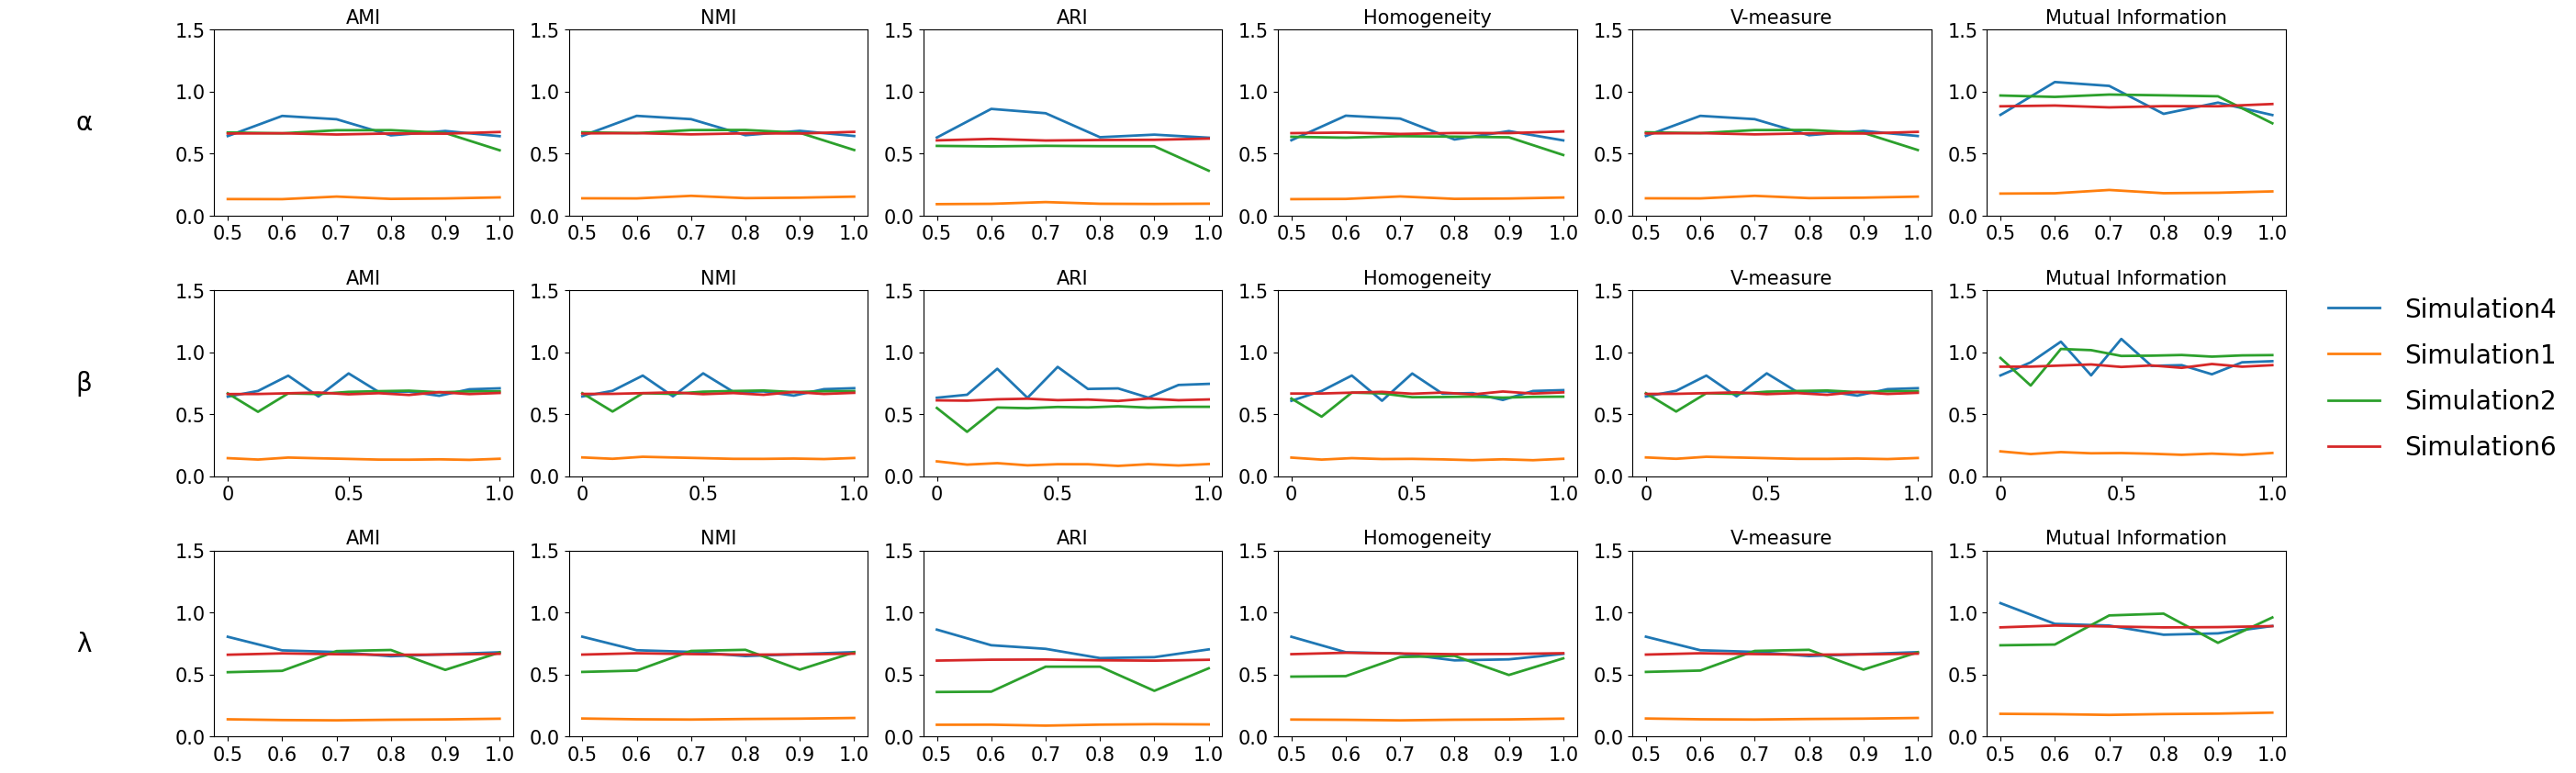

In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 定义指标名称
metrics = ["AMI", "NMI", "ARI", "Homogeneity", "V-measure", "Mutual Information"]

# 定义每个参数的x轴标签
beta_x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
alpha_lambda_x = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# 创建图形
fig = plt.figure(figsize=(32, 10))

# 使用gridspec创建更灵活的布局，左侧为标题区域，右侧为图表区域
gs = gridspec.GridSpec(3, 7, figure=fig, width_ratios=[0.5, 1, 1, 1, 1, 1, 1], hspace=0.4)

# 定义参数信息：(数据, x轴标签, 行索引, 参数名称)
params = [
    (data_alpha, alpha_lambda_x, 0, "α"),
    (data_β, beta_x, 1, "β"),
    (data_lammbda, alpha_lambda_x, 2, "λ")
]

# 绘制每个参数的图表
for data, x_labels, row_idx, param_name in params:
    # 添加行标题，放在左侧单独的列
    ax_title = fig.add_subplot(gs[row_idx, 0])
    ax_title.text(0.5, 0.5, param_name, fontsize=20, 
                  verticalalignment='center', horizontalalignment='center')
    ax_title.axis('off')  # 隐藏坐标轴
    
    # 绘制每个指标的子图
    for col_idx, metric in enumerate(metrics):
        # 计算实际的网格列索引（从1开始，因为0是标题列）
        grid_col = col_idx + 1
        ax = fig.add_subplot(gs[row_idx, grid_col])
        
        for dataset_name, values in data[metric].items():
            # 只在最后一行最后一个子图添加图例标签
            if row_idx == 2 and col_idx == 5:
                ax.plot(values, label=dataset_name, linewidth=2)
            else:
                ax.plot(values, linewidth=2)
        
        # 对β参数特殊处理x轴刻度
        if param_name == "β":
            # 只显示0、0.5和1.0这三个刻度位置
            # 找到它们在beta_x中的索引位置
            tick_positions = [0, 4, 9]  # 对应0.1(索引0)、0.5(索引4)、1.0(索引9)
            tick_labels = [0, 0.5, 1.0]
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels, fontsize=15)
        else:
            ax.set_xticks(range(len(x_labels)))
            ax.set_xticklabels(x_labels, fontsize=15)
            
        ax.set_ylim(0, 1.5)
        ax.set_title(metric, fontsize=15, pad=5)  # pad参数增加标题与图表的距离
        ax.tick_params(axis='y', labelsize=15)

# 添加图例，放在整个图的右侧
handles, labels = fig.axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, 
           loc='center right', 
           bbox_to_anchor=(1, 0.5), 
           fontsize=20,
           frameon=False,  # 去除图例边框
           handletextpad=1,  # 增加图例中图标与文字的间距
           labelspacing=0.8)  # 增加图例行与行之间的距离

# 调整整体布局
plt.tight_layout(rect=[0, 0, 0.93, 1])  # 为右侧图例留出空间
plt.savefig("/home/lixiangyu/multi-omics/MOMG/input/combined_params.jpg", bbox_inches='tight', dpi=300)
plt.show()